# Waves with WWM

**What this shows:** how to add waves to a SCHISM model with WWM, the spectral wave
model that runs inside SCHISM on the same mesh, forced by wave spectra at the open
boundary and by the wind.

**Prerequisites:** [Tutorial 6: A tide and wind hindcast](../tutorial/06_tide_and_wind_hindcast.ipynb).

**You will learn:**

- how `SCHISMDataWave` writes wave spectra at the open boundary
- what the `wwminput` namelist sets, and how it is coupled to SCHISM's time step
- how to run the SCHISM executable built with WWM
- how to read and plot wave output

**Data used:** `hgrid.gr3`, `tides/`, `era5-perth-20230101-05.nc` and
`ww3-spectra-20230101-short.nc`, WAVEWATCH III spectra for 1 January 2023. The run
needs Docker and is skipped without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
    SCHISMDataSflux,
    SCHISMDataWave,
    SfluxAir,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param
from rompy_schism.namelists.wwminput import Wwminput

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "waves_wwm"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
hgrid = grid.pylibs_hgrid

## 1. Wave spectra at the boundary

WAVEWATCH III spectra at points every half degree, three-hourly. The ones at 115°E
lie on the model's western boundary. `SCHISMDataWave` selects the points nearest to
the open boundary and writes their spectra in the WAVEWATCH III format WWM reads;
WWM then interpolates between the two nearest points at each boundary node.

[(113.8, 116.0), (-33.2, -30.8), None, Text(0.5, 1.0, 'Wave spectra')]

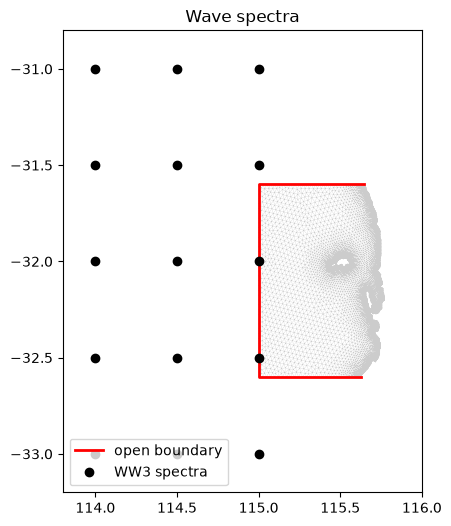

In [2]:
spectra = SourceWavespectra(
    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
)
ww3 = spectra.open()
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(hgrid.x[hgrid.iobn[0]], hgrid.y[hgrid.iobn[0]], "r", linewidth=2, label="open boundary")
ax.triplot(mtri.Triangulation(hgrid.x, hgrid.y, hgrid.elnode[:, :3]), color="0.8", linewidth=0.2)
ax.plot(ww3.lon, ww3.lat, "ko", label="WW3 spectra")
ax.legend(loc="lower left")
ax.set(xlim=(113.8, 116), ylim=(-33.2, -30.8), aspect=ASPECT, title="Wave spectra")

In [3]:
print(f"Hs at the boundary points, 1 January: {ww3.spec.hs().sel(site=[16, 17]).mean().values:.1f} m")
wave = SCHISMDataWave(id="wavedata", source=spectra)

Hs at the boundary points, 1 January: 3.4 m


## 2. The WWM settings

WWM reads its own namelist, `wwminput.nml`, written from `Wwminput`. Its groups set
the spectral grid (`grid`), the physics (`engs`), the numerics (`nums`), the
boundary (`bouc`) and output. rompy-schism fills in:

- the times of every group, from the run's period;
- `bouc.filewave`, the boundary file `SCHISMDataWave` writes.

WWM runs every `opt.nstep_wwm` SCHISM time steps, and its own time step,
`proc.deltc`, must match: here 5 × 120 s = 600 s. With `opt.icou_elfe_wwm=1` the
coupling goes both ways: the waves see SCHISM's water levels and currents, and
SCHISM gets the waves' forces, which set up the water level in the surf zone and
drive longshore currents.

In [4]:
wwminput = Wwminput(proc={"deltc": 600})
spectral = wwminput.grid
print(f"WWM time step: {wwminput.proc.deltc} s")
print(
    f"Spectral grid: {spectral.msc} frequencies from {spectral.frlow} to "
    f"{spectral.frhigh} Hz, {spectral.mdc} directions"
)

WWM time step: 600 s
Spectral grid: 24 frequencies from 0.04 to 1.0 Hz, 24 directions


## 3. The model

The tide and wind model of Tutorial 6, for 1 January, with waves. Wave output:
significant wave height (`iof_wwm(1)`), peak period (`iof_wwm(9)`) and mean
direction (`iof_wwm(7)`), written with the 2D variables.

In [5]:
config = SCHISMConfig(
    grid=grid,
    data=SCHISMData(
        boundary_conditions=SCHISMDataBoundaryConditions(
            tidal_data=TidalDataset(
                tidal_database=DATA_DIR / "tides",
                tidal_model="TPXO9-perth",
                constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
                nodal_corrections=True,
            ),
            default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
        ),
        atmos=SCHISMDataSflux(
            air_1=SfluxAir(
                source=SourceFile(uri=DATA_DIR / "era5-perth-20230101-05.nc"),
                uwind_name="u10",
                vwind_name="v10",
                prmsl_name="msl",
                filter=Filter(sort={"coords": ["latitude"]}),
            )
        ),
        wave=wave,
    ),
    nml=NML(
        param=Param(
            core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 720},
            opt={"wtiminc": 3600.0, "icou_elfe_wwm": 1, "nstep_wwm": 5},
            schout={
                "iof_hydro__1": 1,
                "iof_hydro__16": 1,
                "iof_hydro__26": 0,
                "iof_wwm__1": 1,  # significant wave height
                "iof_wwm__7": 1,  # mean direction
                "iof_wwm__9": 1,  # peak period
            },
        ),
        wwminput=wwminput,
    ),
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-02T00:00", interval="1h")
modelrun = ModelRun(run_id="waves", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
print(sorted(p.name for p in workspace.iterdir() if "wwm" in p.name.lower() or "wave" in p.name))

['hgrid_WWM.gr3', 'wavedata.nc', 'wwmbnd.gr3', 'wwminput.nml']


The boundary group of `wwminput.nml`, with the file and times rompy-schism filled
in. With spectra in the WAVEWATCH III format (`iboundformat=6`), WWM takes the times
from the file itself.

In [6]:
text = (workspace / "wwminput.nml").read_text()
print(text[text.index("&bouc") : text.index("/", text.index("&bouc")) + 1])

&bouc
lbcse = T
lbinter = T
lbcwa = F
lbcsp = T
linhom = T
lbsp1d = F
lbsp2d = T
begtc = '20230101.000000'
deltc = 1
unitc = 'HR'
endtc = '20230102.000000'
filebound = 'wwmbnd.gr3'
iboundformat = 6
filewave = 'wavedata.nc'
lindsprdeg = T
lparmdir = F
wbhs = 2.0
wbss = 2
wbtp = 8.0
wbdm = 90.0
wbdsms = 1
wbds = 10.0
wbgauss = 0.1
wbpken = 3.3
/


## 4. Run

The Docker image has two SCHISM executables: `schism`, hydrodynamics only, and
`schism_wwm`, built with WWM. WWM runs on the compute processes, so the number of
scribes is unchanged.

In [7]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


if docker_available():
    backend = DockerConfig(
        image=SCHISM_IMAGE, executable="schism_wwm 2", mpiexec="mpirun", cpu=6
    )
    modelrun.run(backend, workspace_dir=workspace)
completed = run_completed(workspace)
print("SCHISM finished" if completed else "SCHISM did not finish")

SCHISM finished


## 5. Wave output

Wave variables are in the `out2d` files with the others.

In [8]:
if completed:
    out2d = xr.open_mfdataset(
        sorted((workspace / "outputs").glob("out2d_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip
    print([name for name in out2d.data_vars if "Wave" in name or "Period" in name])

['sigWaveHeight', 'meanWaveDirection', 'peakPeriod']


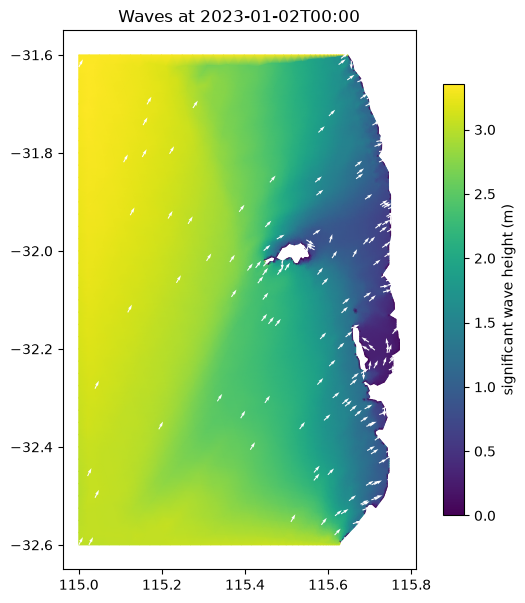

In [9]:
if completed:
    x, y = out2d.SCHISM_hgrid_node_x.values, out2d.SCHISM_hgrid_node_y.values
    triangulation = mtri.Triangulation(x, y, out2d.SCHISM_hgrid_face_nodes.values[:, :3] - 1)
    last = out2d.isel(time=-1)
    fig, ax = plt.subplots(figsize=(7, 7))
    tpc = ax.tripcolor(
        triangulation, last.sigWaveHeight, cmap="viridis", shading="gouraud"
    )
    fig.colorbar(tpc, ax=ax, label="significant wave height (m)", shrink=0.8)
    step = 40
    direction = np.radians(last.meanWaveDirection.values[::step])
    # Nautical convention: the direction the waves come from, clockwise from north
    ax.quiver(
        x[::step], y[::step], -np.sin(direction), -np.cos(direction),
        color="w", scale=40, width=0.003,
    )  # fmt: skip
    ax.set(title=f"Waves at {str(last.time.values)[:16]}", aspect=ASPECT)

Wave height and peak period over the day at a point offshore and at Cottesloe beach
(times in UTC, 8 hours behind Perth). The model starts from calm seas, so the first
hours are a spin-up. Rottnest Island and the reefs shelter the coast from most of the
offshore swell: about 1 m reaches Cottesloe out of 3 to 4 m offshore. The peak period
is that of the swell, 14 s, except in the late afternoon at Cottesloe (08 to 12 UTC),
when the sea breeze raises a wind sea larger than the sheltered swell. It jumps
between values because it is the frequency of the spectrum's largest bin; more
frequencies (`grid.msc`) give finer steps.

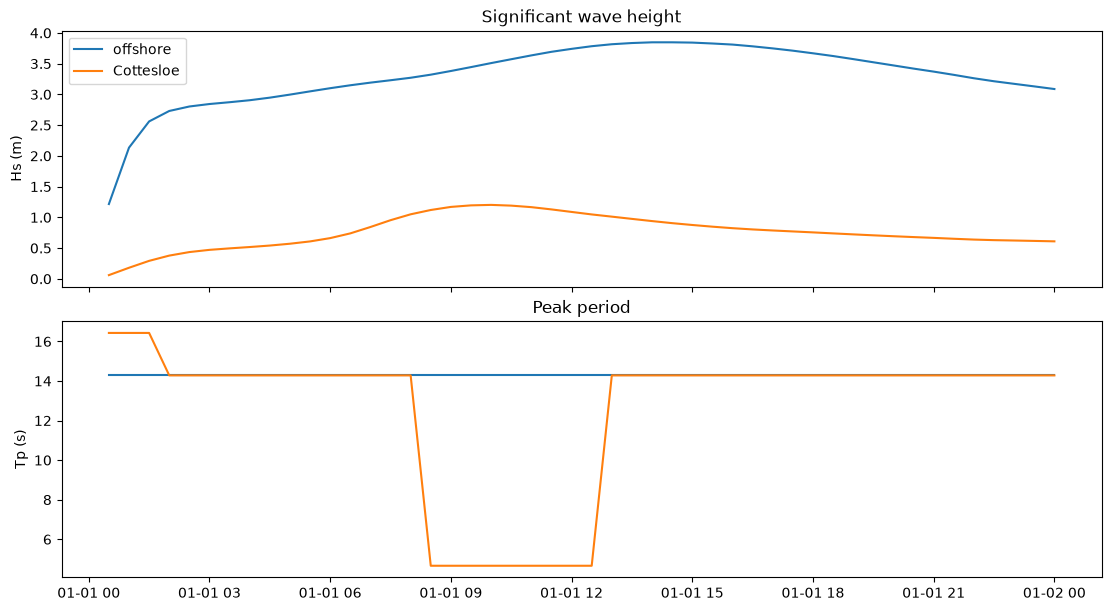

In [10]:
if completed:
    points = {"offshore": (115.2, -32.0), "Cottesloe": (115.74, -31.99)}
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
    for name, (lon, lat) in points.items():
        node = np.argmin((x - lon) ** 2 + (y - lat) ** 2)
        axes[0].plot(out2d.time, out2d.sigWaveHeight[:, node], label=name)
        axes[1].plot(out2d.time, out2d.peakPeriod[:, node], label=name)
    axes[0].set(ylabel="Hs (m)", title="Significant wave height")
    axes[1].set(ylabel="Tp (s)", title="Peak period")
    axes[0].legend()

## Summary

- `SCHISMDataWave` writes spectra at the open boundary from a wave model;
  rompy-schism points `wwminput.nml` to it and sets WWM's times from the period.
- `Wwminput` holds WWM's settings; keep `proc.deltc` equal to `dt × nstep_wwm`.
- `opt.icou_elfe_wwm=1` couples waves and currents both ways.
- Run the WWM executable (`schism_wwm` in the Docker image); wave output is in the
  `out2d` files.